In [20]:
%matplotlib inline
import numpy as np
from matplotlib_inline import backend_inline
from d2l import torch as d2l


def f(x):
    return 3 * x ** 2 - 4 * x

In [21]:
def numerical_lim(f, x, h):
    return (f(x + h) - f(x)) / h

h = 0.1
for i in range(5):
    print(f'h={h:.5f}, numerical limit={numerical_lim(f, 1, h):.5f}')
    h *= 0.1

h=0.10000, numerical limit=2.30000
h=0.01000, numerical limit=2.03000
h=0.00100, numerical limit=2.00300
h=0.00010, numerical limit=2.00030
h=0.00001, numerical limit=2.00003


In [22]:
def use_svg_display():  #@save
    """使用svg格式在Jupyter中显示绘图"""
    backend_inline.set_matplotlib_formats('svg')

In [23]:
def set_figsize(figsize=(10, 5)):  #@save
    """设置matplotlib的图表大小"""
    use_svg_display()
    d2l.plt.rcParams['figure.figsize'] = figsize

In [24]:
#@save
def set_axes(axes, xlabel, ylabel, xlim, ylim, xscale, yscale, legend):
    """设置matplotlib的轴"""
    axes.set_xlabel(xlabel)
    axes.set_ylabel(ylabel)
    axes.set_xscale(xscale)
    axes.set_yscale(yscale)
    axes.set_xlim(xlim)
    axes.set_ylim(ylim)
    if legend:
        axes.legend(legend)
    axes.grid()

In [27]:
#@save
def plot(X, Y=None, xlabel=None, ylabel=None, legend=None, xlim=None,
         ylim=None, xscale='linear', yscale='linear',
         fmts=('-', 'm--', 'g-.', 'r:'), figsize=(10, 5), axes=None):
    """绘制数据点"""
    if legend is None:
        legend = []

    set_figsize(figsize)
    axes = axes if axes else d2l.plt.gca()

    # 如果X有一个轴，输出True
    def has_one_axis(X):
        return (hasattr(X, "ndim") and X.ndim == 1 or isinstance(X, list)
                and not hasattr(X[0], "__len__"))

    if has_one_axis(X):
        X = [X]
    if Y is None:
        X, Y = [[]] * len(X), X
    elif has_one_axis(Y):
        Y = [Y]
    if len(X) != len(Y):
        X = X * len(Y)
    axes.cla()
    for x, y, fmt in zip(X, Y, fmts):
        if len(x):
            axes.plot(x, y, fmt)
        else:
            axes.plot(y, fmt)
    set_axes(axes, xlabel, ylabel, xlim, ylim, xscale, yscale, legend)

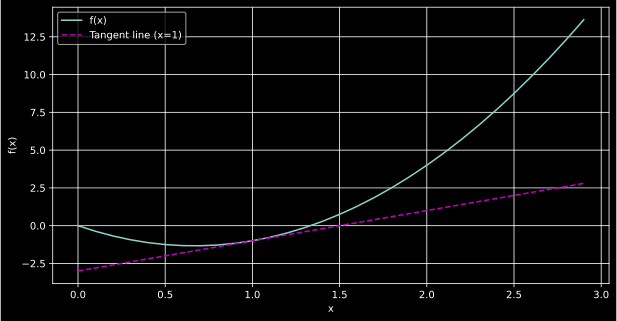

In [28]:
x = np.arange(0, 3, 0.1)
plot(x, [f(x), 2 * x - 3], 'x', 'f(x)', legend=['f(x)', 'Tangent line (x=1)'])

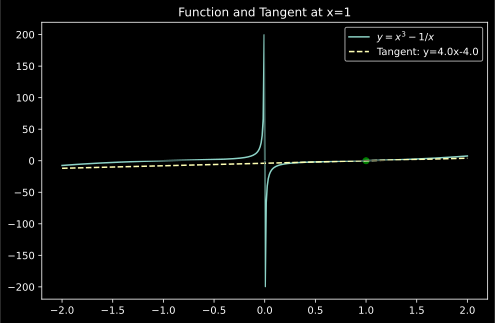

2. 梯度: [6. 5.]
3. 梯度: [0.6 0.8]
4. du/da: 22.610943901069348  du/db: 3.221887802138699


In [32]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 绘制函数与切线
def f(x):
    return x**3 - 1/x
def df(x):
    return 3*x**2 + 1/(x**2)

x = np.linspace(-2, 2, 400)
x = x[x != 0]
y = f(x)
x0, y0 = 1, f(1)
k = df(x0)
tangent_y = k*(x - x0) + y0

plt.figure(figsize=(8,5))
plt.plot(x, y, label=r'$y=x^3-1/x$')
plt.plot(x, tangent_y, '--', label=f'Tangent: y={k}x-{k}')
plt.scatter(x0, y0, c='green')
plt.axhline(0, c='k', lw=0.5)
plt.axvline(0, c='k', lw=0.5)
plt.legend()
plt.title('Function and Tangent at x=1')
plt.show()

# 2. 梯度 f(x1,x2)=3x1²+5e^x2
def grad_f2(x):
    return np.array([6*x[0], 5*np.exp(x[1])])
print("2. 梯度:", grad_f2([1,0]))

# 3. 梯度 f(x)=||x||₂
def grad_f3(x):
    return x / np.linalg.norm(x)
print("3. 梯度:", grad_f3([3,4]))

# 4. 链式法则示例
def f4(x,y,z): return x**2 + y**3 + z*np.exp(y)
def x(a,b): return a+b
def y(a,b): return a*b
def z(a,b): return a-b
def du_da(a,b):
    return 2*x(a,b)*1 + (3*y(a,b)**2 + z(a,b)*np.exp(y(a,b)))*b + np.exp(y(a,b))*1
def du_db(a,b):
    return 2*x(a,b)*1 + (3*y(a,b)**2 + z(a,b)*np.exp(y(a,b)))*a + np.exp(y(a,b))*(-1)
print("4. du/da:", du_da(1,2), " du/db:", du_db(1,2))